# Predict wether a telecom customer wil terminate the contract

## imports

### Libraries

In [1]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


### Data

In [4]:
df = pd.read_csv('../DataBases/TelecomChurn/TelecomChurn.csv')

#### Variable Breakdown

- STATE: 51 Unique States in United States of America
- Account Length. Length of The Account
- Area Code 415 relates to San Francisco,408 is of San Jose and 510 is of City of Okland
- International Plan Yes Indicate International Plan is Present and No Indicates no subscription for Internatinal Plan
- Voice Mail Plan Yes Indicates Voice Mail Plan is Present and No Indicates no subscription for Voice Mail Plan
- Number vmail messages Number of Voice Mail Messages ranging from 0 to 50
- Total day minutes Total Number of Minutes Spent By Customers in Morning
- Total day calls Total Number of Calls made by Customer in Morning.
- Total day charge Total Charge to the Customers in Morning.
- Total eve minutesTotal Number of Minutes Spent By Customers in Evening
- Total eve calls Total Number of Calls made by Customer in Evening.
- Total eve charge Total Charge to the Customers in Evening.
- Total night minutes Total Number of Minutes Spent By Customers in the Night.
- Total night calls Total Number of Calls made by Customer in Night.
- Total night charge Total Charge to the Customers in Night.

## EDA

In [5]:
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

==> there are no missing values in the dataset

==> ['state', 'international plan', 'voice mail plan'] need to be encoded

==> 'churn' can be encoded

**==> What about 'phone number'?**

In [7]:
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


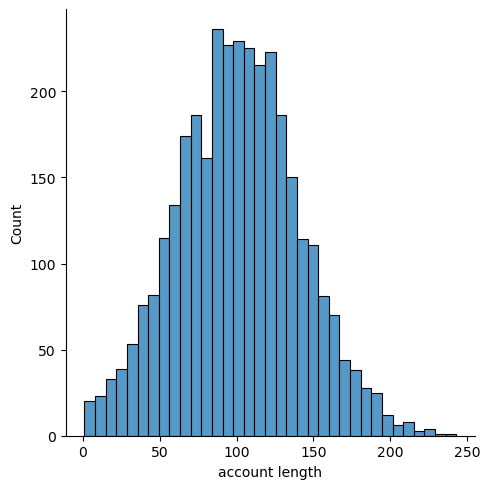

In [8]:
# some customers stay just for 1 month, and then they leave.
# but most of them stay mutiple years

sns.displot(x=df['account length'])

In [9]:
df.describe(exclude = np.number)

,state,phone number,international plan,voice mail plan,churn
count,3333,3333,3333,3333,3333
unique,51,3333,2,2,2
top,WV,382-4657,no,no,False
freq,106,1,3010,2411,2850


==> phone number can be deleted. There is no added value from it as all values are distinct

==> most customers don't have neither international nor voice mail plans

==> most customers don't quit their contracts (churn=False)

==> this is an UNBALANCED dataset

In [10]:
df.nunique()

state                       51
account length             212
area code                    3
phone number              3333
international plan           2
voice mail plan              2
number vmail messages       46
total day minutes         1667
total day calls            119
total day charge          1667
total eve minutes         1611
total eve calls            123
total eve charge          1440
total night minutes       1591
total night calls          120
total night charge         933
total intl minutes         162
total intl calls            21
total intl charge          162
customer service calls      10
churn                        2
dtype: int64

In [11]:
# valores nulos?
df.isnull().sum()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

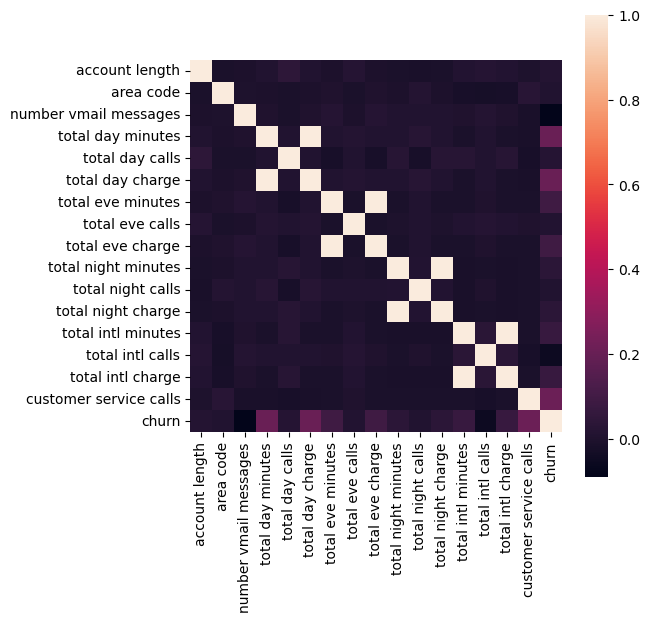

In [12]:
# identificar correlações
plt.figure(figsize=(6,6))
sns.heatmap(df.corr(numeric_only=True), square=True)
plt.show()

==> **What can we conclude from this?**

Very strong correlation between day charge and total day minutes (/eve/night/intl)

==> Drop ['total day charge','total eve charge', 'total night charge', 'total intl charge']

<Figure size 600x600 with 0 Axes>

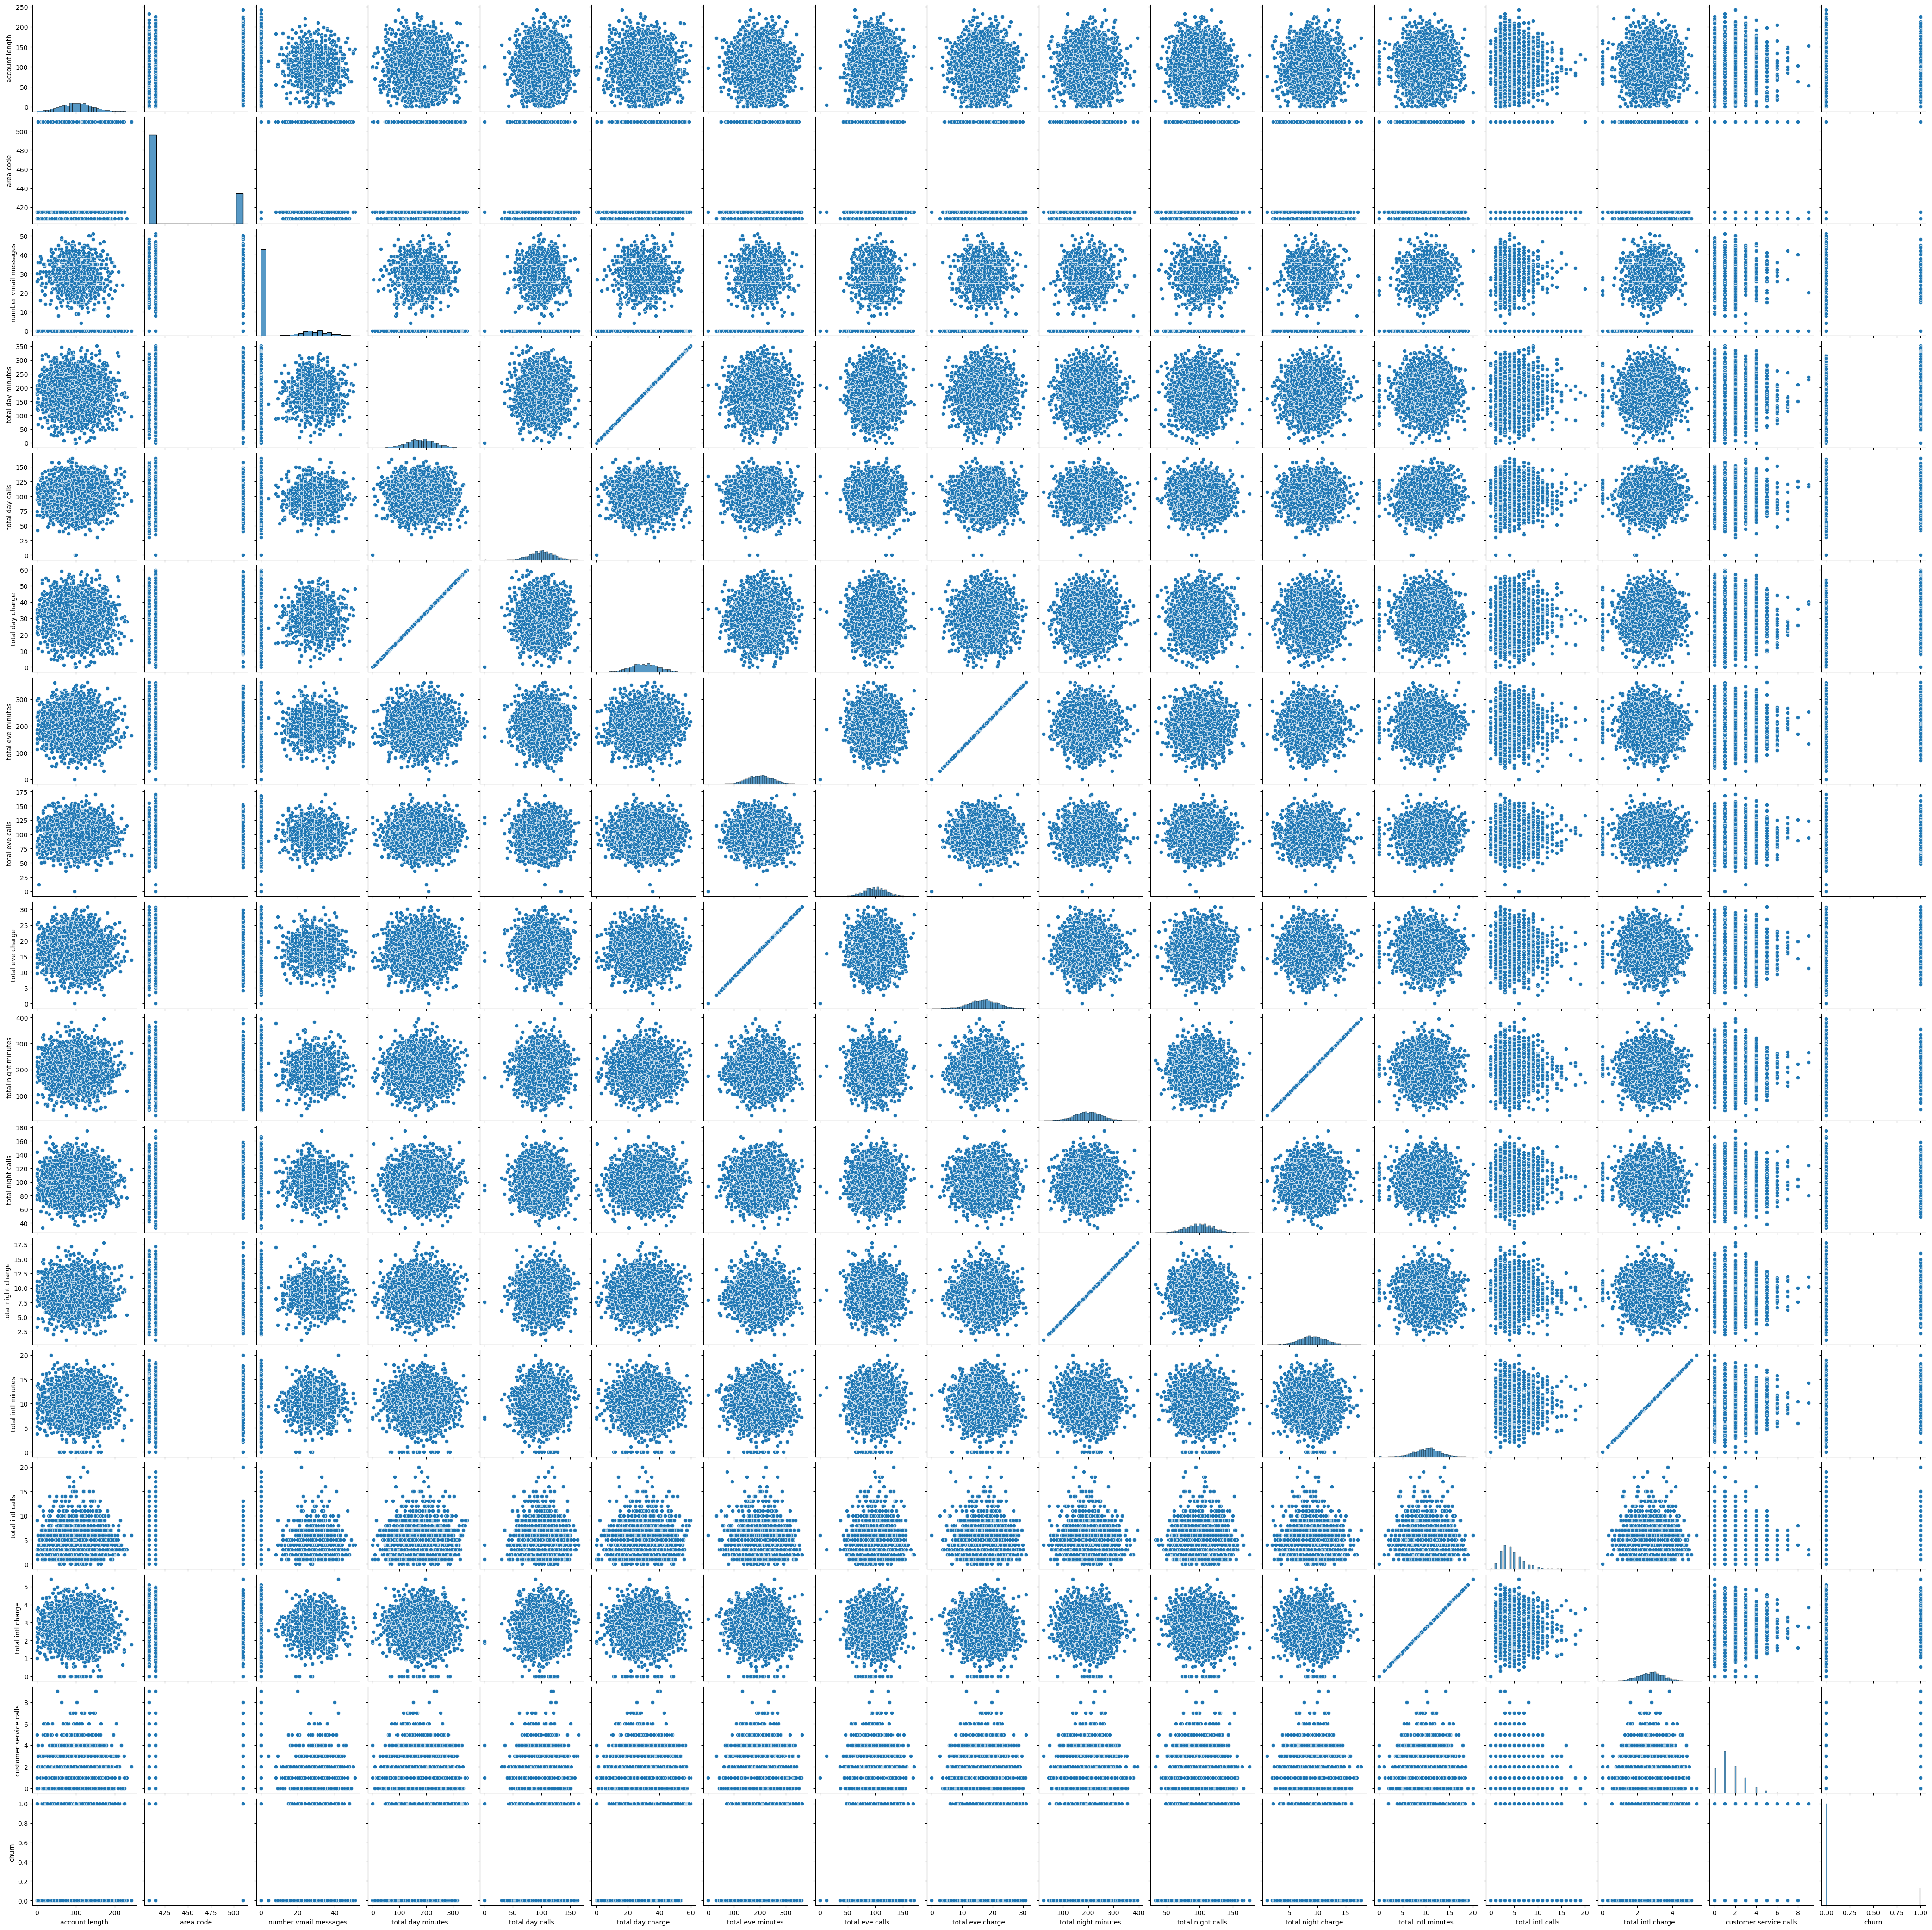

In [13]:
# skiping this as it is heavy on the cpu
plt.figure(figsize = (6,6))
sns.pairplot(df)
plt.show()

In [14]:
# análise dos valores do Churn
churnCount = df['churn'].value_counts()
churnCount

churn
False    2850
True      483
Name: count, dtype: int64

==> Dataset MUITO desbalanceado

In [15]:
churnCount[True]/df['churn'].count()

np.float64(0.14491449144914492)

In [16]:
# Are customers with more calls more prone to churn?
# and that behaviour depends on the time of calls?

# Lets sepparate our df into two: Churn and noChurn
# and use those new dataframes to plot histograms of the Churns/noChurns per number of calls

churns=df[df.churn==1]
noChurns = df[df.churn==0]

Text(0.5, 1.0, ' No Churns')

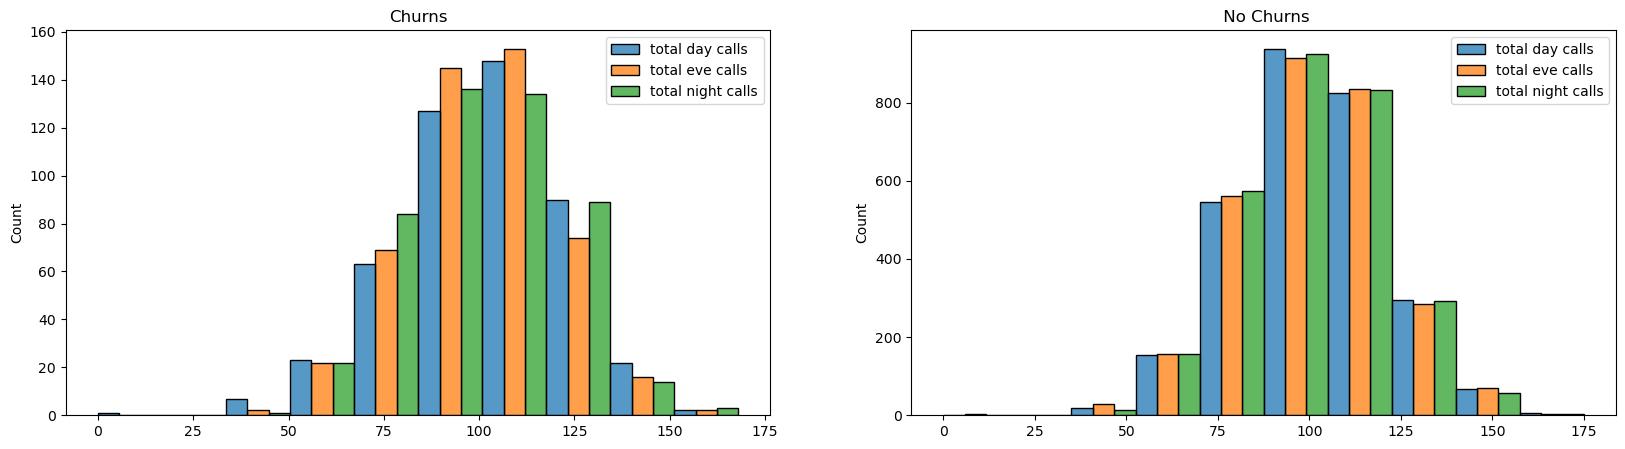

In [17]:
fig, axes = plt.subplots(1,2, figsize=(20,5))

sns.histplot(ax=axes[0], data=churns[['total day calls','total eve calls', 'total night calls']], multiple='dodge', bins=10)
axes[0].set_title('Churns')
             
sns.histplot(ax=axes[1], data=noChurns[['total day calls','total eve calls', 'total night calls']], multiple='dodge', bins=10)
axes[1].set_title(' No Churns')
                                    

==> The number of calls (total day/evening/night calls) is not a significant differentiating factor in predicting churn.

==> Both customers who cancel ("Churns") and those who remain ("No Churns") show nearly identical behavior regarding the number of calls they make, whether during the day, at night, or in the late afternoon.

==> These three columns (total day calls, total eve calls, and total night calls) alone will have low predictive power.

==> "If the number of calls doesn't matter, what could matter?" Perhaps variables like:

==> Call Cost or Duration (total day/eve/night charge or minutes). Perhaps customers don't care about how many calls they make, but rather how much they pay for them.

==> Customer Service Calls. This is a classic predictor of churn; dissatisfied customers call support more.

==> Additional Plans and Services (international plan, voicemail plan).

Text(0.5, 1.0, ' No Churns')

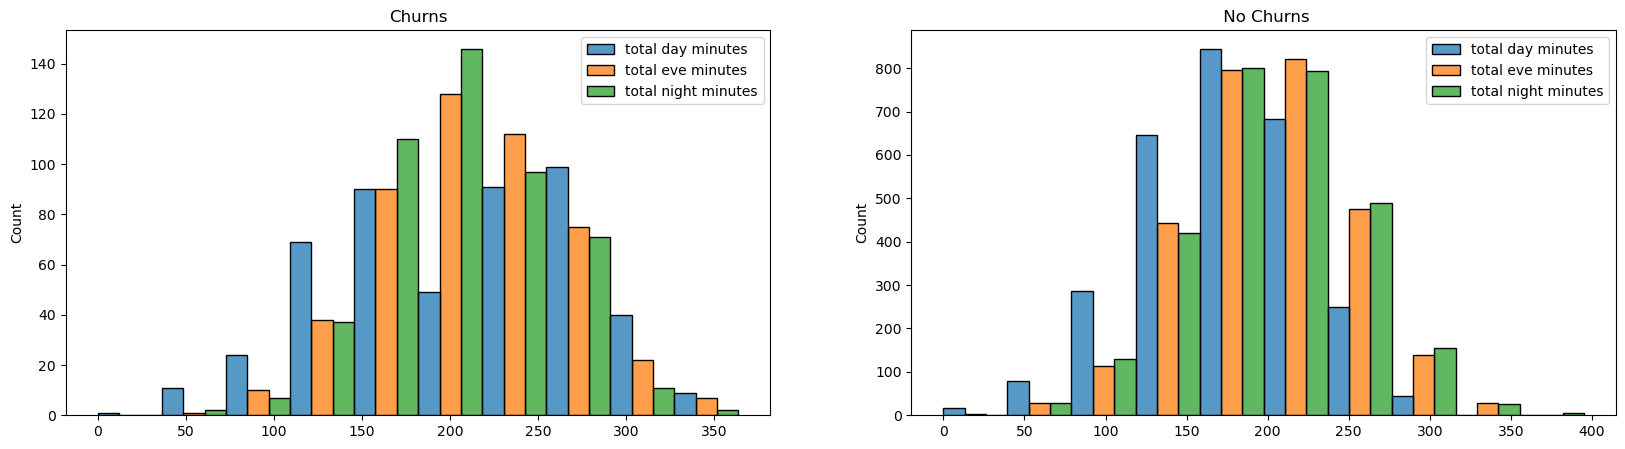

In [18]:
fig, axes = plt.subplots(1,2, figsize=(20,5))

sns.histplot(ax=axes[0], data=churns[['total day minutes','total eve minutes', 'total night minutes']], multiple='dodge', bins=10)
axes[0].set_title('Churns')
             
sns.histplot(ax=axes[1], data=noChurns[['total day minutes','total eve minutes', 'total night minutes']], multiple='dodge', bins=10)
axes[1].set_title(' No Churns')
                                    

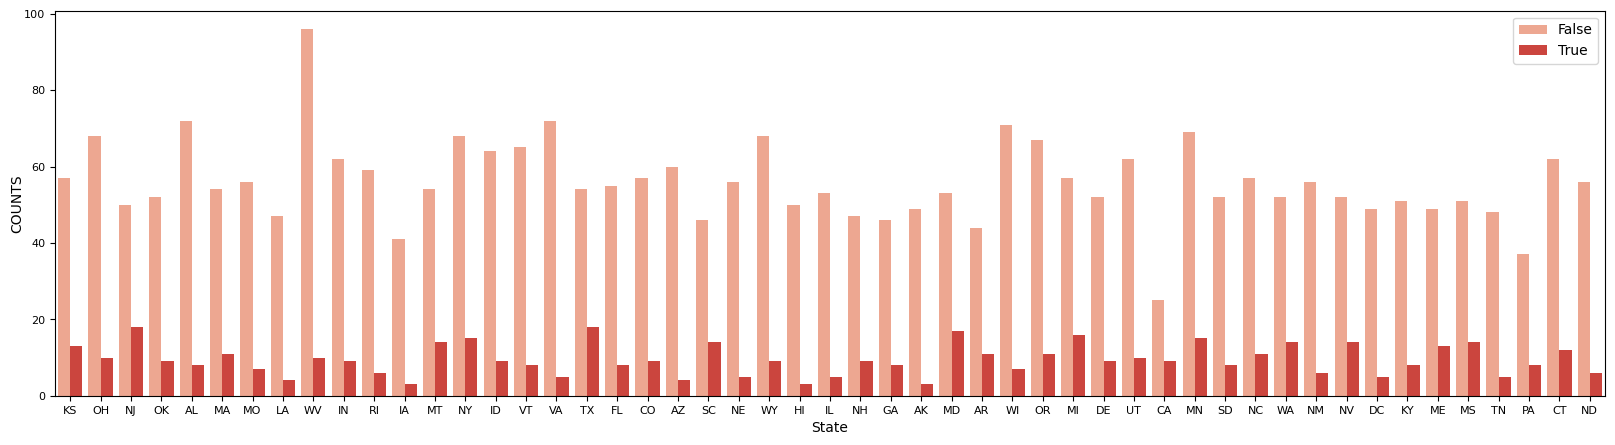

In [19]:
# Churn counting per state

fig, axz = plt.subplots(figsize=(20,5))

axz = sns.countplot(x='state', hue='churn', data=df, palette='Reds')


axz.set_ylabel('COUNTS', rotation=90,size=10)
axz.set_xlabel('State', size=10)
axz.yaxis.set_label_coords(-0.02, 0.5)  # (x, y)
axz.legend(loc=0,fontsize= 10);

axz.tick_params(labelsize=8) 

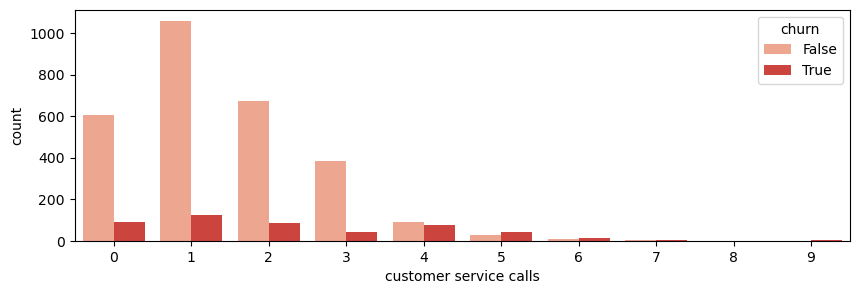

In [20]:
# Customer Service Calls analysis

fig, axes = plt.subplots(figsize=(10,3))

axes =  sns.countplot(x='customer service calls', hue='churn', data=df, palette='Reds')

==> What can we conclude from this?

For customers with less than 4 calls, the percentage of those who stay is higher. Customer support works!   
Customers with 4 calls have a churn rate close to 50%.   
For customers with more than 4 calls, the churn rate is over 50%.

The Customer Service Calls variable is an __extremely strong__ and crucial predictor of churn.

What about Total Day Minutes

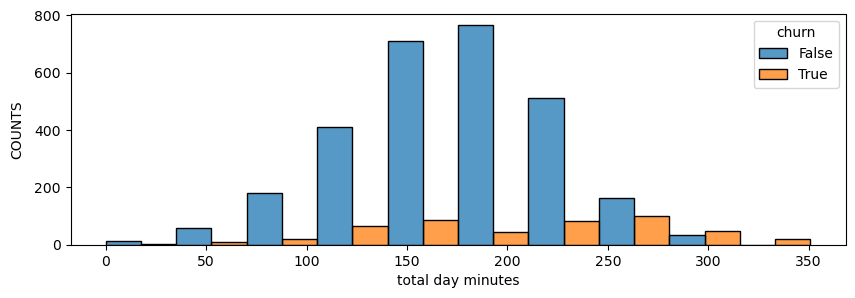

In [21]:
fig, axz = plt.subplots(figsize=(10,3))

axz = axz = sns.histplot(data = df,x='total day minutes', hue='churn', multiple='dodge',bins=10)

axz.set_ylabel('COUNTS', rotation=90, labelpad=100,size=10)
axz.set_xlabel('total day minutes', size=10)
axz.yaxis.set_label_coords(-0.06, 0.5)  # (x, y)
axz.tick_params(labelsize=10)

## Pre-processing

In [22]:
# descartar colunas desnecessárias

columns2drop = ['phone number', 'total day charge', 'total eve charge', 'total night charge', 'total intl charge']
df = df.drop(columns2drop, axis=1)

In [23]:
# codificar churn

from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()

df['churn'] = enc.fit_transform(df['churn'])


In [24]:
# codificar 'state', 'international plan', 'voice mail plan'

from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

columns2encode = ['state', 'international plan', 'voice mail plan']

encoded_data = encoder.fit_transform(df[columns2encode])

encoder.categories_

[array(['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA',
        'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME',
        'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM',
        'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX',
        'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY'], dtype=object),
 array(['no', 'yes'], dtype=object),
 array(['no', 'yes'], dtype=object)]

In [25]:
feature_names =  encoder.get_feature_names_out(columns2encode)

encoded_df = pd.DataFrame(encoded_data, columns=feature_names)
df2=pd.concat([df, encoded_df], axis=1)

df=df2.drop(columns2encode, axis=1)

## Split

In [26]:
y=df['churn']
X=df.drop(['churn'],axis=1)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test =  train_test_split (X, y,
                                                      test_size=0.25,
                                                      random_state=24,
                                                      stratify=y)

In [28]:
y_train.sum()/y_train.count()

np.float64(0.1448579431772709)

In [29]:
y_test.sum()/y_test.count()

np.float64(0.145083932853717)

## Train

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

In [31]:
results_df=pd.DataFrame(columns=['Model','Accuracy','Precision','Recall','f1-score'])

def evaluate(reais, previstos):
    _accuracy = accuracy_score(reais, previstos)
    _precision = precision_score(reais, previstos)
    _recall = recall_score(reais, previstos)
    _f1 = f1_score(reais, previstos, average='weighted')
    return round(_accuracy,2), round(_precision,2), round(_recall,2), round(_f1,5)

def print_evaluate(model, reais, previstos):  
    accuracy, precision, recall, f1 = evaluate(reais, previstos)
    print('__________________________________')
    print('Accuracy:', accuracy)
    print('Precision:', precision)
    print('Recall:', recall)
    print('F1:', f1)
    print('__________________________________')
    results=np.array([model,accuracy, precision, recall, f1])
    results_df.loc[len(results_df)+1]=results

### XGBoost

In [32]:
##!pip install xgboost

In [33]:
import xgboost as xgb

In [160]:
xgb_rf_c = xgb.XGBRFClassifier(random_state=24)

xgb_rf_c.fit(X_train, y_train)

xgb_pred = xgb_rf_c.predict(X_test)

print_evaluate("XGB", y_test, xgb_pred)

NameError: name 'X_train' is not defined

<Axes: >

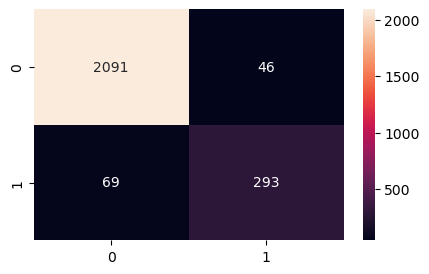

In [161]:
# Confusion Matrix with training data
train_predictions = xgb_rf_c.predict(X_train)#[:, 1]
cm = confusion_matrix(y_train, train_predictions)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')

<Axes: >

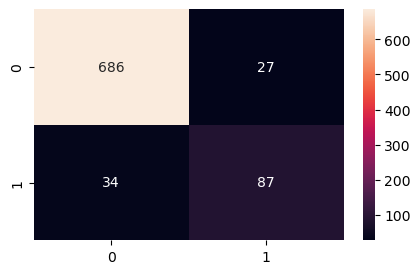

In [162]:
# Confusion Matrix with test data
test_predictions = xgb_rf_c.predict(X_test)#[:, 1]
cm = confusion_matrix(y_test, test_predictions)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

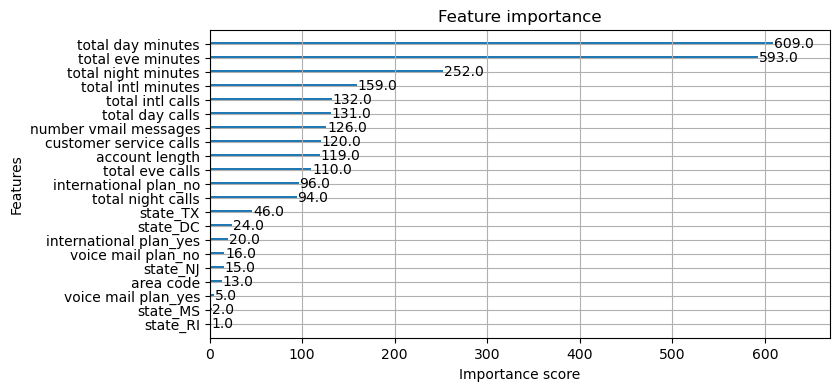

In [163]:
from xgboost import plot_importance

fig, ax = plt.subplots(1,1,figsize=(8,4))
plot_importance(xgb_rf_c, ax=ax)


In [164]:
xgb_rf_c.get_params()

{'colsample_bynode': 0.8,
 'learning_rate': 1.0,
 'reg_lambda': 1e-05,
 'subsample': 0.8,
 'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 24,
 'reg_alpha': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

#### Search for XGBoost's best hyperparameters 

In [165]:
####
from sklearn.model_selection import GridSearchCV

In [166]:
from time import time

def grid_search(_model, _params, _X, _y):
    GSCV = GridSearchCV(estimator=_model
                    ,param_grid=_params
                    ,cv=5
                    ,n_jobs = -1
                    ,verbose = 1)
    start = time()
    GSCV.fit(_X,_y)
    grid_time = time() - start
    print("Grid time:", grid_time)
    print(GSCV.best_params_) 
    return GSCV.best_params_

In [167]:
# A parameter grid for XGBoost
params_xgb = {
        #'min_child_weight': [1, 5],
        'gamma': [None, 7,10, 15],
        'n_estimators':[None, 100, 150,200],
        #'subsample': [0.4, 0.8, 1.0],
        'colsample_bytree': [None, 0.8, 1],
        'max_depth': [None, 5, 10,15]
        }

params_xgb = {
        'colsample_bytree': [None, 0.99, 0.9],
        'gamma': [None, 1, 10],
        'max_depth': [None, 20, 15],
        'min_child_weight': [None, 5],
        'n_estimators': [None, 100]
        }

In [168]:
model=xgb.XGBRFClassifier(random_state = 24)
best_params=grid_search(model, params_xgb, X_train, y_train)

# Create a new XGBoost Classifier
xgb_2=xgb.XGBRFClassifier(
    min_child_weight  = best_params['min_child_weight'],
    gamma             = best_params['gamma'],
    colsample_bytree  = best_params['colsample_bytree'],
    n_estimators      = best_params['n_estimators'],
    max_depth         = best_params['max_depth'],
    random_state      = 24
)


# Train it
xgb_2.fit(X_train, y_train)

# Make predictions on the test dataset
xgb_2_pred = xgb_2.predict(X_test)

print_evaluate("XGB optimized", y_test, xgb_2_pred)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Grid time: 24.494728088378906
{'colsample_bytree': 0.9, 'gamma': None, 'max_depth': 20, 'min_child_weight': None, 'n_estimators': None}
__________________________________
Accuracy: 0.93
Precision: 0.78
Recall: 0.72
F1: 0.92811
__________________________________


In [169]:
best_params

{'colsample_bytree': 0.9,
 'gamma': None,
 'max_depth': 20,
 'min_child_weight': None,
 'n_estimators': None}

<Axes: >

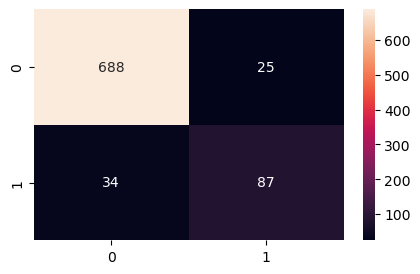

In [170]:
# Confusion Matrix with test data
cm = confusion_matrix(y_test, xgb_2_pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='d')

## Resampling

In [171]:
## !pip3 install imblearn

### OverSampling with SMOTE

In [172]:
from imblearn.over_sampling import SMOTE


#### Oversampling train data to 1:1)

In [173]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train==1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train==0)))

sm = SMOTE(random_state=24)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('After OverSampling, the shape of train_X: {}'.format(X_train_res.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_train_res.shape))

print("After OverSampling, counts of label '1': {}".format(sum(y_train_res==1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_train_res==0)))



Before OverSampling, counts of label '1': 362
Before OverSampling, counts of label '0': 2137 

After OverSampling, the shape of train_X: (4274, 67)
After OverSampling, the shape of train_y: (4274,) 

After OverSampling, counts of label '1': 2137
After OverSampling, counts of label '0': 2137


In [174]:
####
# Create a new XGBoost Classifier
xgb_3=xgb.XGBRFClassifier(
    min_child_weight  = best_params['min_child_weight'],
    gamma             = best_params['gamma'],
    colsample_bytree  = best_params['colsample_bytree'],
    n_estimators      = best_params['n_estimators'],
    max_depth         = best_params['max_depth'],
    random_state      = 24
)

# Train it
xgb_3.fit( X_train_res, y_train_res, verbose = False)

# Make predictions on the test dataset
xgb_3_pred = xgb_3.predict(X_test)

print_evaluate("XGB optimized with SMOTE", y_test, xgb_3_pred)

__________________________________
Accuracy: 0.94
Precision: 0.81
Recall: 0.78
F1: 0.94073
__________________________________


<Axes: >

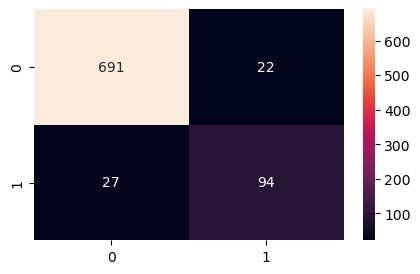

In [175]:
# Confusion Matrix with test data
cm = confusion_matrix(y_test, xgb_3_pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='d')

In [176]:
# Optimize the model using the oversampled dataset

model=xgb.XGBRFClassifier(random_state = 24)
best_params=grid_search(model, params_xgb, X_train_res, y_train_res)

# Create a new XGBoost Classifier
xgb_4=xgb.XGBRFClassifier(
    min_child_weight  = best_params['min_child_weight'],
    gamma             = best_params['gamma'],
    colsample_bytree  = best_params['colsample_bytree'],
    n_estimators      = best_params['n_estimators'],
    max_depth         = best_params['max_depth'],
    random_state      = 24
)


# Train it
xgb_4.fit(X_train_res, y_train_res)

# Make predictions on the test dataset
xgb_4_pred = xgb_4.predict(X_test)

print_evaluate("XGB optimized", y_test, xgb_4_pred)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Grid time: 69.1243360042572
{'colsample_bytree': 0.9, 'gamma': None, 'max_depth': 20, 'min_child_weight': None, 'n_estimators': None}
__________________________________
Accuracy: 0.94
Precision: 0.81
Recall: 0.78
F1: 0.94073
__________________________________


<Axes: >

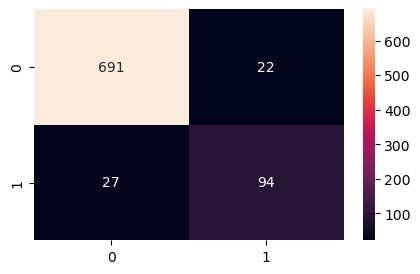

In [177]:
# Confusion Matrix with test data
cm = confusion_matrix(y_test, xgb_4_pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='d')

#### Oversampling with a limit

In [178]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train==1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train==0)))

sm = SMOTE(random_state=24,sampling_strategy={1:800})
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print('After OverSampling, the shape of train_X: {}'.format(X_train_res.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_train_res.shape))

print("After OverSampling, counts of label '1': {}".format(sum(y_train_res==1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_train_res==0)))



Before OverSampling, counts of label '1': 362
Before OverSampling, counts of label '0': 2137 

After OverSampling, the shape of train_X: (2937, 67)
After OverSampling, the shape of train_y: (2937,) 

After OverSampling, counts of label '1': 800
After OverSampling, counts of label '0': 2137


In [179]:
# Optimize the model using the new oversampled dataset

model=xgb.XGBRFClassifier()
best_params=grid_search(model, params_xgb, X_train_res, y_train_res)

# Create a new XGBoost Classifier
xgb_5=xgb.XGBRFClassifier(
    min_child_weight  = best_params['min_child_weight'],
    gamma             = best_params['gamma'],
    colsample_bytree  = best_params['colsample_bytree'],
    n_estimators      = best_params['n_estimators'],
    max_depth         = best_params['max_depth'],
    random_state      = 24
)


# Train it
xgb_5.fit(X_train_res, y_train_res)

# Make predictions on the test dataset
xgb_5_pred = xgb_5.predict(X_test)

print_evaluate("XGB optimized with SMOTE w/ limits", y_test, xgb_5_pred)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Grid time: 27.975841283798218
{'colsample_bytree': 0.9, 'gamma': 1, 'max_depth': 20, 'min_child_weight': None, 'n_estimators': None}
__________________________________
Accuracy: 0.94
Precision: 0.83
Recall: 0.76
F1: 0.94141
__________________________________


<Axes: >

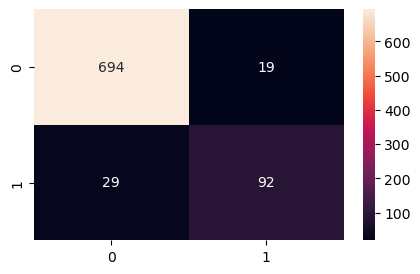

In [180]:
# Confusion Matrix with test data
cm = confusion_matrix(y_test, xgb_5_pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='d')

### Undersampling

In [181]:
from imblearn.under_sampling import RandomUnderSampler

In [182]:

# define undersample strategy
#undersample = RandomUnderSampler(sampling_strategy="majority")
undersample = RandomUnderSampler(sampling_strategy=0.2, random_state=24)

# fit and apply the transform
X_train_under, y_train_under = undersample.fit_resample(X_train, y_train)
print("X:", X_train.shape, "-->", X_train_under.shape)
print("y:", y_train.shape, "-->",y_train_under.shape)

X: (2499, 67) --> (2172, 67)
y: (2499,) --> (2172,)


In [183]:
model=xgb.XGBRFClassifier()
best_params=grid_search(model, params_xgb, X_train_under, y_train_under)

# Create a new XGBoost Classifier
xgb_6=xgb.XGBRFClassifier(
    min_child_weight  = best_params['min_child_weight'],
    gamma             = best_params['gamma'],
    colsample_bytree  = best_params['colsample_bytree'],
    n_estimators      = best_params['n_estimators'],
    max_depth         = best_params['max_depth'],
    random_state      = 24
)


# Train it
xgb_6.fit(X_train_under, y_train_under)

# Make predictions on the test dataset
xgb_6_pred = xgb_6.predict(X_test)

print_evaluate("XGB optimized with SMOTE w/ limits and Under", y_test, xgb_6_pred)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Grid time: 14.641728401184082
{'colsample_bytree': 0.9, 'gamma': 1, 'max_depth': 20, 'min_child_weight': None, 'n_estimators': None}
__________________________________
Accuracy: 0.93
Precision: 0.78
Recall: 0.73
F1: 0.92946
__________________________________


<Axes: >

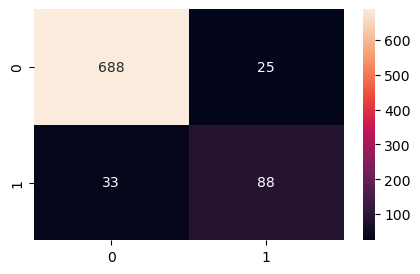

In [184]:
# Confusion Matrix with test data
cm = confusion_matrix(y_test, xgb_6_pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='d')

In [185]:
results_df

,Model,Accuracy,Precision,Recall,f1-score
1,XGB,0.93,0.76,0.72,0.92595
2,XGB optimized,0.93,0.78,0.72,0.92811
3,XGB optimized with SMOTE,0.94,0.81,0.78,0.94073
4,XGB optimized,0.94,0.81,0.78,0.94073
5,XGB optimized with SMOTE w/ limits,0.94,0.83,0.76,0.94141
6,XGB optimized with SMOTE w/ limits and Under,0.93,0.78,0.73,0.92946


In [186]:
xgb_5.get_params()

{'colsample_bynode': 0.8,
 'learning_rate': 1.0,
 'reg_lambda': 1e-05,
 'subsample': 0.8,
 'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bytree': 0.9,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': 1,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 20,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 24,
 'reg_alpha': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}